# 📝 Hypothesis Testing Worksheet: The Case of the Suspicious Factory

---
## 🔍 Your Turn to Be the Inspector!

In the lecture, we investigated an exam scenario. Now, it's your turn to apply the same reasoning to a real-world quality control case.

### 🏭 The New Case

A factory claims that their production line produces **only 10% defective products** — a very strict quality standard.

A quality control inspector is skeptical. She randomly selects **20 items** from the latest batch and finds **8 defective items**.

The factory manager protests:

> *"Our machines are fine! You just got an unusually bad batch by random chance!"*

The inspector must decide: **Is the factory's claim believable, or is there strong evidence that the true defect rate is higher than 10%?**

Your task is to conduct a hypothesis test to help the inspector make a decision.

---
**The Hypothesis Testing Framework:**
*   **H₀ (Null Hypothesis):** The factory's claim is **true** — the defect rate is 10%.
*   **H₁ (Alternative Hypothesis):** The factory's claim is **false** — the defect rate is **higher** than 10%.
*   **Evidence:** The inspector found **8 defective items out of 20**.
*   **Threshold (α):** We'll use the standard **α = 0.05**.

---

In [1]:
# ── Setup: Run this cell first ──────────────────────────────
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

np.random.seed(42)  # Set a seed for reproducible results

print("🔍 Worksheet Ready! Let's investigate the factory.")

🔍 Worksheet Ready! Let's investigate the factory.


---

### Step 1: State the Hypotheses (Question 1)

First, we need to clearly define our two hypotheses in the context of this quality control problem.

> **Question 1:** Fill in the blanks below to correctly state H₀ and H₁.

**H₀ (The Factory's Claim):** The production process is working correctly. The probability that any single item is defective is ______.

**H₁ (The Inspector's Concern):** The production process has a problem. The probability that any single item is defective is ______ than the factory's claim.

*Hint: What probability did the factory claim for defective items?*

*Type your answer to Question 1 here:*

H₀: The production process is working correctly. The probability that any single item is defective is ______ (**10%**).

H₁: The production process has a problem. The true defect rate is **greater** than **10%**.

---

### Step 2: The Threshold (α)

The inspector's agency has a standard rule: **"If a perfectly-functioning factory (10% defect rate) would produce a batch this bad (or worse) less than 10% of the time, we will flag the factory for a full audit."**

> **Question 2:** What is our significance level (α)?

*Type your answer to Question 2 here:*

α = 0.05

---

### Step 3: Build the Null Distribution (Simulation)

Now, let's simulate what results look like if the factory's claim is **true**. We'll simulate 10,000 batches of 20 items, where each item has a 10% (0.10) chance of being defective — exactly as the factory claims.

> **Question 3:** Complete the code below to perform the simulation.

In [2]:
# ── Your Task: Simulate 10,000 batches under H₀ ──

n_batches   = 10000
n_items     = 20
defect_prob = 0.10  # Factory's claimed defect rate

# TODO: Use np.random.binomial to simulate the number of defective items
#       in each of the 10,000 batches.
# Hint: The syntax is np.random.binomial(n, p, size)

null_defects = np.random.binomial(n_items,defect_prob, n_batches)

# --- Check your answer ---
print("Simulation complete!")
print(f"  Average defects per batch (simulated): {null_defects.mean():.2f}")   # complete this
print(f"  Expected average (n × p): {n_items * defect_prob:.2f}")

Simulation complete!
  Average defects per batch (simulated): 1.97
  Expected average (n × p): 2.00


> **Question 4:** Based on the simulation results printed above, how many defective items would you *expect* in a batch of 20 if the factory's 10% claim is true? Does the inspector's finding of 8 defective items already seem surprising to you?

*Your answer to Question 4:*
out of 20 only 2 item should be defective, if factory's 10% claim is true but 8 defective items show claim false


---

### Step 4: Look at the Evidence

The inspector found **8 defective items out of 20**. Let's see how this compares to our simulated distribution of batches from a well-functioning factory.

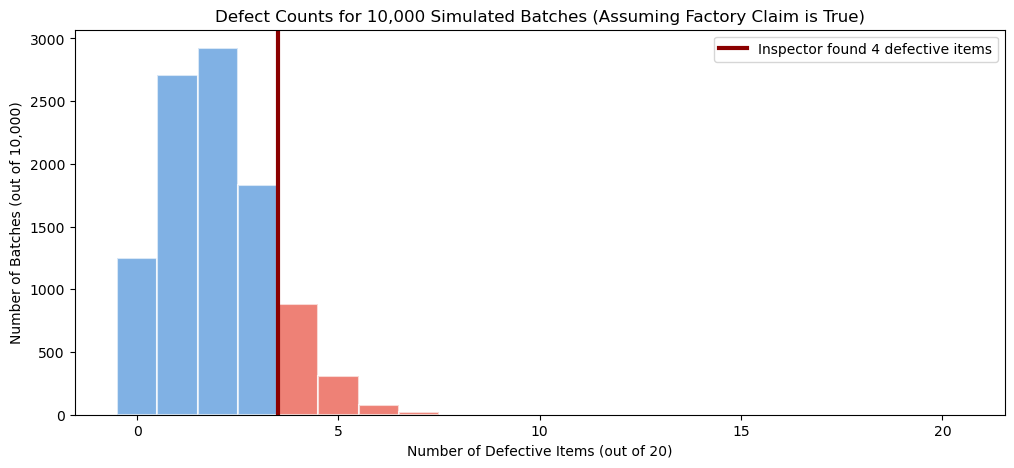

Visually, does finding 4 defectives look common or rare if H₀ is true? rare, Ho claim is not true


In [10]:
# ── Visualize the Null Distribution with the inspector's finding ──

observed_defects = 4

plt.figure(figsize=(12, 5))

# Create a histogram of defect counts from the simulated batches
counts, bins, patches = plt.hist(null_defects, bins=range(0, 22), align='left',
                                  color='#4A90D9', alpha=0.7, edgecolor='white', linewidth=1.5)

# TODO: Change the color of bars for defect counts >= observed_defects to '#E74C3C' (red).
# Hint: Loop through the 'patches' object. Each patch has a .set_facecolor() method.
# The index of the patch corresponds to the defect count.
for i, patch in enumerate(patches):
    if i >= observed_defects:
        patch.set_facecolor('#E74C3C')


plt.axvline(x=observed_defects - 0.5, color='darkred', linestyle='-', linewidth=3,
            label=f'Inspector found {observed_defects} defective items')
plt.xlabel('Number of Defective Items (out of 20)')
plt.ylabel('Number of Batches (out of 10,000)')
plt.title('Defect Counts for 10,000 Simulated Batches (Assuming Factory Claim is True)')
plt.legend()
plt.show()

print(f"Visually, does finding {observed_defects} defectives look common or rare if H₀ is true? rare, Ho claim is not true")

> **Question 5:** After looking at the chart, does finding 8 defective items look like a common or a rare outcome if the factory's 10% claim were really true?

*Your answer to Question 5:*
rare , claim reject


---

### Step 5: Calculate the p-value

Now, let's calculate the precise p-value. Remember, the p-value is the probability of observing results **this extreme or more extreme** if H₀ were true.

In our case: **What is the probability of finding 8 or more defective items** in a batch of 20, if the true defect rate really is only 10%?

> **Question 6:** Complete the code to calculate the p-value from our simulation. Then, interpret its meaning.

In [11]:
# ── Your Task: Calculate the p-value from the simulation ──

# TODO: Count how many simulated batches had >= observed_defects (which is 8).
count_extreme = np.sum(null_defects >= observed_defects)

# Calculate p-value
p_value = count_extreme / n_batches

# TODO: Calculate the p-value by dividing that count by the total number of batches.

print(f"Number of simulated batches with 8 or more defects: {count_extreme}")  # complete this
print(f"p-value (simulation) = {p_value:.4}")                               # complete this

print(f"\n🔍  Interpreting the p-value:")
print(f"    'If the factory's claim were true (10% defect rate),")
print(f"     there is a {p_value*100:.2f}% chance of seeing")                    # complete this
print(f"     {observed_defects} or more defectives in a batch of 20 just by random variation.'") 

Number of simulated batches with 8 or more defects: 1284
p-value (simulation) = 0.1284

🔍  Interpreting the p-value:
    'If the factory's claim were true (10% defect rate),
     there is a 12.84% chance of seeing
     4 or more defectives in a batch of 20 just by random variation.'


> **Question 7:** In your own words, what does this specific p-value tell us about the inspector's finding of 8 defective items out of 20?

*Your answer to Question 7:*
If the factory's claim is true (H₀ is true), getting 8 or more defective items would occur in only 0.05% of cases.
This means it is a very rare event.


---

### Step 6: Make the Decision (Question 8)

We now have our p-value and our threshold (α = 0.05).

> **Question 8:** Fill in the blanks to make the correct decision.

*Complete the following:*

**Decision Rule:**
If p-value < α, we reject H₀ and conclude the defect rate is greater than 10%.

If p-value ≥ α, we fail to reject H₀ and conclude we don't have enough evidence to dispute the factory's claim.

**Our Comparison:**
Our p-value (0.0005) is less than α (0.05).

**The Verdict:**  
Therefore, we reject H₀. The inspector's official conclusion is **defect rate is greater than 10%**.

*Your completed answer to Question 8:*

**Decision Rule:**  
If p-value < α, we **______** H₀ and conclude the defect rate is **______** than 10%.
If p-value ≥ α, we **______** H₀ and conclude we don't have enough evidence to dispute the factory's claim.

**Our Comparison:**  
Our p-value (**______**) is **______** α (0.05).

**The Verdict:**  
Therefore, we **______** H₀. The inspector's official conclusion is **______________________**.

**Does this verdict mean the factory is definitely producing too many defective items?**

*(yes, because 0.05% chances that 8 defective item out of 20 that is very rare, inspector claim is true and factory claims reject)*

---

## Bonus Challenge: The Exact p-value

Simulations are great, but we can also calculate the exact p-value using the binomial distribution formula.

We want the probability of finding **8 or more** defective items out of 20, when the true defect probability is 0.05.

This is: **P(X ≥ 8) = 1 − P(X ≤ 7)**

> **Bonus Task:** Use `stats.binom.cdf()` to calculate the exact p-value and compare it to our simulated value.

In [16]:
# ── Bonus: Calculate the exact p-value ──────────────────────

# TODO: Use stats.binom.cdf(k, n, p) to calculate P(X ≤ 7)
# Then, calculate the exact p-value as 1 - P(X ≤ 7)
p_value_exact = 1 - stats.binom.cdf(k=3, n=20, p=0.10)


print(f"Exact p-value     = {p_value_exact:.6f}")   # complete this
print(f"Simulated p-value = {p_value:.6f}")   # complete this
print("\nWhy are these numbers slightly different?")

Exact p-value     = 0.132953
Simulated p-value = 0.128400

Why are these numbers slightly different?


*Your answer to the Bonus question:*
The numbers are slightly different because the simulation is based on random sampling. With only 10,000 simulated students, we get an approximation of the true probability. The exact p-value (0.0004) is the true mathematical probability. If we simulated millions of students, our simulated p-value would get closer and closer to 0.0005.


---

## 🏁 Finished! Great Work, Inspector.

You've successfully applied the entire hypothesis testing framework to a real-world quality control problem. The key takeaways are the same, no matter the context:

1.  We **assume the null hypothesis is true** (H₀ — the factory's claim is correct).
2.  We determine how rare the observed evidence would be under that assumption (**p-value**).
3.  If the evidence is rare enough (p-value < **α**), we reject our assumption and side with H₁.

---